In [1]:
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, to_hex
import matplotlib.patches as mpatch
import matplotlib.colors as mc
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import axes3d, art3d, proj3d

from astropy.io import fits, ascii
from astropy.wcs import WCS
from astropy import units as u
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord, Longitude, Latitude
from astropy.wcs.utils import skycoord_to_pixel, pixel_to_skycoord
from astropy.convolution import convolve_fft, Gaussian2DKernel
from astropy.table import Table, vstack, Column, QTable
from astropy.stats import mad_std
from astropy.visualization.wcsaxes import add_beam

import astrodendro
from astrodendro import dendrogram 
from astrodendro.analysis import PPVStatistic
from astrodendro.structure import Structure
from regions import RectangleSkyRegion, RectanglePixelRegion, Regions
import regions 

from spectral_cube import SpectralCube
from skimage.transform import resize

import glob
import os
import re
import io
from math import ceil

basepath = '/home/j_poz/documents/milkywaylab/data'

In [154]:
be_tbl=Table.read(f'{basepath}/tables/HVCC_resampled_subcube_regions.ecsv')
tbl=Table.read(f'{basepath}/tables/HVCC_resampled_again.ecsv')
be_tbl.sort('ID Number')

cube = SpectralCube.read(f'{basepath}/images/hi_res_cubes/EVF_89_CS21_l-0.007_b-0.045.fits')
slab = cube.spectral_slab((be_tbl['min_v'][89])*u.km/u.s, (be_tbl['max_v'][89])*u.km/u.s)
slab_noise = mad_std(slab.unmasked_data[:].value, ignore_nan=True)

cs_hdu = SpectralCube.read(f'{basepath}/images/CS21_CubeMosaic_downsampled9.fits')
downsampled_slab = cs_hdu.spectral_slab((be_tbl['min_v'][89])*u.km/u.s, (be_tbl['max_v'][89])*u.km/u.s)
downsampled_mom0 = downsampled_slab.moment(order=0)
downsampled_pv = downsampled_slab.moment(order=0, axis=1)

sig_level = 3
ACES_FWHM = 3.194 #arcsec
ACES_sig = ACES_FWHM / 2.355 #arcsec
pix_scale = 0.0001*3600  #deg/pix to arcsec/pix
ACES_kern = ACES_sig/pix_scale

In [3]:
d = astrodendro.Dendrogram.compute(slab.unmasked_data[:].value, min_value=sig_level*slab_noise, 
                                   min_npix=14, min_delta=sig_level*slab_noise)

#wcs = cube.wcs
#mask = np.zeros(cube.hdu.data.shape, dtype=bool)

#median_int = []
#intensities = []
#for leaf in d.leaves:
#    leaf_mask = leaf.get_mask()
#    mi = np.median(cube.unmasked_data[leaf_mask].value)
#    intensity = cube.unmasked_data[leaf_mask].value
#    intensities.append(intensity)
#    median_int.append(mi)
    
#intensities = list(itertools.chain.from_iterable(intensities))    
#top_leaves = np.array(d.leaves)[np.where(median_int>np.median(intensities))]

In [6]:
tbl.add_index('ID Number')
cent = SkyCoord(tbl.loc[89]['l']*u.deg, tbl.loc[89]['b']*u.deg, frame='galactic')


In [26]:
i = 1

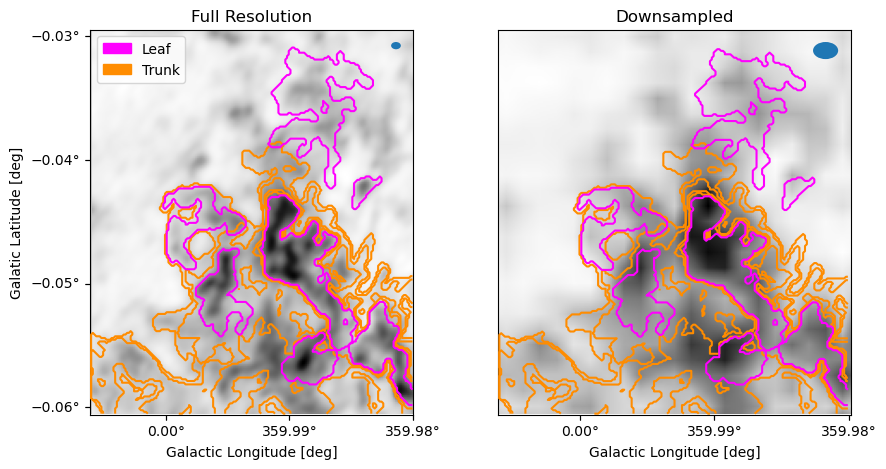

In [105]:
slab_wcs = slab.moment(order=0).wcs

fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121, projection=slab_wcs)
ax2 = fig.add_subplot(122, projection=slab_wcs)

###
lon1 = ax1.coords[0]
lat1 = ax1.coords[1]

lon1.set_major_formatter('d.dd')
lat1.set_major_formatter('d.dd')
ax1.set_ylabel('Galatic Latitude [deg]', fontsize=10)
ax1.set_xlabel('Galactic Longitude [deg]', fontsize=10)
ax1.tick_params(axis='x', labelsize=10)
ax1.tick_params(axis='y', labelsize=10)

lon1.set_ticks_position('b')
lon1.set_ticklabel_position('b')
lon1.set_axislabel_position('b')
lat1.set_ticks_position('l')
lat1.set_ticklabel_position('l')
lat1.set_axislabel_position('l')

lon2 = ax2.coords[0]
lat2 = ax2.coords[1]

lon2.set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude [deg]', fontsize=10)
ax2.tick_params(axis='x', labelsize=10)
lon2.set_ticks(values=[0.00, 359.99, 359.98]*u.deg)


lon2.set_ticks_position('b')
lon2.set_ticklabel_position('b')
lon2.set_axislabel_position('b')
lat2.set_ticklabel_visible(False)
lat2.set_ticks_visible(False)
###

ax1.imshow(slab.moment(order=0).value, cmap='Grays', origin='lower')

mins = pixel_to_skycoord(ax1.get_xlim()[1], ax1.get_ylim()[0], wcs=slab_wcs)
maxs = pixel_to_skycoord(ax1.get_xlim()[0], ax1.get_ylim()[1], wcs=slab_wcs)

cutout=Cutout2D(downsampled_mom0.data, cent, size=[(maxs.b-mins.b), (360*u.deg+maxs.l-mins.l)], wcs=downsampled_mom0.wcs)
new = resize(cutout.data, (225,189))

ax2.imshow(new, cmap='Grays', origin='lower', aspect='auto')

for leaf in d.all_structures:
    
    if leaf.is_leaf:
        ax1.contour(np.sum(leaf.get_mask(), axis=0), colors='fuchsia', levels=0)
        ax2.contour(np.sum(leaf.get_mask(), axis=0), colors='fuchsia', levels=0)
  
    else:
        ax1.contour(np.sum(leaf.get_mask(), axis=0), colors='darkorange', levels=0) 
        ax2.contour(np.sum(leaf.get_mask(), axis=0), colors='darkorange', levels=0) 
    


ax1.set_title('Full Resolution')
ax2.set_title('Downsampled')

ax1.legend(handles=[mpatch.Patch(color='fuchsia', label='Leaf'), mpatch.Patch(color='darkorange', label='Trunk')], loc='upper left')


fr_beam = add_beam(ax1, cube.header, corner='top right')
ds_beam = add_beam(ax2, major=6.74*u.arcsec, minor=5*u.arcsec, angle=90*u.deg, corner='top right')

#fig.savefig(f'{basepath}/images/dendro_contours.pdf')

In [102]:
new.shape

(225, 189)

In [13]:
pv = slab.moment(order=0, axis=1)
pv_wcs = pv.wcs

In [14]:
pv.shape

(20, 188)

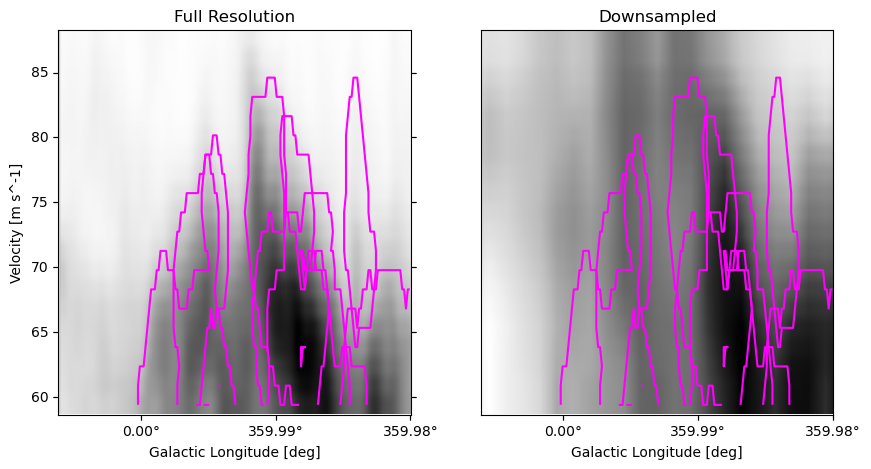

In [155]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121, projection=pv_wcs)
ax2 = fig.add_subplot(122, projection=pv_wcs)

###
lon1 = ax1.coords[0]
vel1 = ax1.coords[1]

lon1.set_major_formatter('d.dd')
ax1.set_ylabel(r'Velocity [m s^-1]', fontsize=10)
ax1.set_xlabel('Galactic Longitude [deg]', fontsize=10)
ax1.tick_params(axis='x', labelsize=10)
ax1.tick_params(axis='y', labelsize=10)
vel1.set_format_unit(u.km/u.s)

lon1.set_ticks_position('b')
lon1.set_ticklabel_position('b')
lon1.set_axislabel_position('b')


lon2 = ax2.coords[0]
vel2 = ax2.coords[1]

lon2.set_major_formatter('d.dd')
ax2.set_xlabel('Galactic Longitude [deg]', fontsize=10)
ax2.tick_params(axis='x', labelsize=10)
lon2.set_ticks(values=[0.00, 359.99, 359.98]*u.deg)

lon2.set_ticks_position('b')
lon2.set_ticklabel_position('b')
lon2.set_axislabel_position('b')
lon2.set_ticklabel_visible(True)
lon2.set_ticks_visible(True)
vel2.set_ticklabel_visible(False)
vel2.set_ticks_visible(False)
###

ax1.imshow(pv.value, cmap='Grays', origin='lower', aspect='auto')

xp = x_max_lores+(x_min_lores-x_max_lores)/2
yp = ax2.get_ylim()[0]+(ax2.get_ylim()[1]-ax2.get_ylim()[0])/2

cutout_pv = Cutout2D(downsampled_pv.data, position=(xp,yp), size=(20,21))
new_pv = resize(cutout_pv.data, (20, 188))

ax2.imshow(new_pv, cmap='Grays', origin='lower', aspect='auto')

x_max_hires = pixel_to_skycoord(ax1.get_xlim()[0], 0, wcs=slab_wcs)
x_min_hires = pixel_to_skycoord(ax1.get_xlim()[1], 0, wcs=slab_wcs)
x_max_lores = skycoord_to_pixel(x_max_hires, wcs=downsampled_mom0.wcs)[0]
x_min_lores = skycoord_to_pixel(x_min_hires, wcs=downsampled_mom0.wcs)[0]


for leaf in d.all_structures:
    cont_lv = np.sum(leaf.get_mask(), axis=1)
    cont_rs = resize(cont_lv, (20, 21))
    if leaf.is_leaf:
        ax1.contour(cont_lv, colors='fuchsia', levels=0)
        ax2.contour(cont_lv, colors='fuchsia', levels=0)
    else:
        continue
        ax1.contour(cont_lv, colors='darkorange', levels=0) 
        ax2.contour(cont_lv, colors='darkorange', levels=0) 



ax1.set_title('Full Resolution')
ax2.set_title('Downsampled')

#ax1.legend(handles=[mpatch.Patch(color='fuchsia', label='Leaf'), mpatch.Patch(color='darkorange', label='Trunk')], loc='upper left')

fig.savefig(f'{basepath}/figs/dendro_contours_lv.pdf')

In [138]:
pv.shape

(20, 188)